In [15]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, f1_score
from imblearn.over_sampling import RandomOverSampler

KONFIGURASI PATH

In [16]:
BASE = r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT"
GDB  = fr"{BASE}\2022_RBI25K_KAB_BANYUMAS_KUGI50_20221231.gdb"
GADM = fr"{BASE}\indonesiaSHPLevel3\gadm41_IDN_3.shp"
OUT  = Path(fr"{BASE}\outputs"); OUT.mkdir(parents=True, exist_ok=True)

# ---------- Util ----------
def p99(x): 
    return np.nanpercentile(x, 99)

1) DATA COLLECTING & CLEANING  → shapefile layer dasar

In [17]:
bms_adm = gpd.read_file(GADM)
bms_adm = bms_adm[bms_adm["NAME_2"] == "Banyumas"].to_crs(32749)
bms_boundary = bms_adm.dissolve(by="NAME_2")

# Layer tematik dari GDB
layer_hijau = ["HUTANLAHANTINGGI_AR_25K","HUTANLAHANRENDAH_AR_25K","HERBADANRUMPUT_AR_25K","HUTANTANAMAN_AR_25K"]
layer_bgn   = ["PERUMAHAN_AR_25K","PERMUKIMAN_AR_25K"]
layer_jln   = "JALAN_LN_25K"

hijau_list = [gpd.read_file(GDB, layer=l) for l in layer_hijau]
area_hijau = gpd.GeoDataFrame(pd.concat(hijau_list, ignore_index=True), crs=hijau_list[0].crs).to_crs(32749)

bgn_list   = [gpd.read_file(GDB, layer=l) for l in layer_bgn]
bangunan   = gpd.GeoDataFrame(pd.concat(bgn_list, ignore_index=True), crs=bgn_list[0].crs).to_crs(32749)

jalan      = gpd.read_file(GDB, layer=layer_jln).to_crs(32749)

# Clip ke batas Banyumas
area_hijau = gpd.clip(area_hijau, bms_boundary)
bangunan   = gpd.clip(bangunan,   bms_boundary)
jalan      = gpd.clip(jalan,      bms_boundary)

2) GRID GENERATION → data grid

In [18]:
minx, miny, maxx, maxy = bms_boundary.total_bounds
GRID_SIZE = 1000  # m

cols = np.arange(minx, maxx, GRID_SIZE)
rows = np.arange(miny, maxy, GRID_SIZE)

grid_cells = [box(x, y, x + GRID_SIZE, y + GRID_SIZE) for x in cols for y in rows]
grid = gpd.GeoDataFrame({"geometry": grid_cells}, crs=bms_boundary.crs)
grid = gpd.overlay(grid, bms_boundary, how="intersection").reset_index(drop=True)
grid["grid_id"] = np.arange(1, len(grid) + 1)
grid["cell_area_m2"] = grid.geometry.area

# Tambah atribut kecamatan (NAME_3 → kecamatan)
assert "NAME_3" in bms_adm.columns, f"Kolom NAME_3 tidak ada. Kolom tersedia: {bms_adm.columns.tolist()}"
grid = gpd.sjoin(grid, bms_adm[["NAME_3","geometry"]], how="left", predicate="intersects")\
         .rename(columns={"NAME_3":"kecamatan"}).drop(columns=["index_right"])


3) FEATURE ENGINEERING → variabel numerik per grid
    (luas hijau, luas bangunan, panjang jalan + turunan)

In [22]:
def _require_gdf(x, name):
    if x is None:
        raise ValueError(f"Layer '{name}' belum diisi (None). Berikan GeoDataFrame yang valid.")
    if not isinstance(x, gpd.GeoDataFrame):
        raise TypeError(f"Layer '{name}' harus GeoDataFrame, bukan {type(x)}.")
    if x.empty:
        raise ValueError(f"Layer '{name}' kosong.")
    if "geometry" not in x.columns:
        raise ValueError(f"Layer '{name}' tidak memiliki kolom 'geometry'.")
    return x

def _to_metric_crs_like(target_gdf, *others):
    """Samakan semua CRS ke CRS metrik (estimasi UTM dari 'target_gdf')."""
    if target_gdf.crs is None:
        raise ValueError("GeoDataFrame target tidak memiliki CRS. Tetapkan CRS (mis. EPSG:4326) terlebih dulu.")
    metric_crs = target_gdf.estimate_utm_crs() or target_gdf.crs
    tgt = target_gdf.to_crs(metric_crs)
    out = [o.to_crs(metric_crs) if o.crs != metric_crs else o for o in others]
    return (tgt, *out)

def _detect_kecamatan_col(adm_gdf):
    kandidat = ["kecamatan", "KECAMATAN", "NamaKec", "NAME_4", "NAME_3", "WADMKC"]
    ada = [c for c in kandidat if c in adm_gdf.columns]
    if not ada:
        raise KeyError(
            "Tidak menemukan kolom nama kecamatan pada layer administrasi. "
            f"Kolom yang tersedia: {list(adm_gdf.columns)}.\n"
            "Tambahkan/rename dulu salah satu kolom menjadi salah satu dari "
            f"{kandidat}."
        )
    return ada[0]

def build_grid_features(grid, adm_kecamatan, bangunan, area_hijau, jalan):
    # 0) Validasi input
    grid         = _require_gdf(grid, "grid")
    adm_kecamatan= _require_gdf(adm_kecamatan, "adm_kecamatan")
    bangunan     = _require_gdf(bangunan, "bangunan")
    area_hijau   = _require_gdf(area_hijau, "area_hijau")
    jalan        = _require_gdf(jalan, "jalan")

    # 1) Samakan CRS ke metrik (UTM estimasi dari grid) agar area/length valid
    grid, adm_kecamatan, bangunan, area_hijau, jalan = _to_metric_crs_like(
        grid, adm_kecamatan, bangunan, area_hijau, jalan
    )

    # 2) grid_id & luas sel
    if "grid_id" not in grid.columns:
        grid = grid.copy()
        grid["grid_id"] = np.arange(1, len(grid) + 1)
    if "cell_area_m2" not in grid.columns:
        grid = grid.copy()
        grid["cell_area_m2"] = grid.geometry.area

    # 3) Tambahkan kolom kecamatan via sjoin (kalau belum ada)
    if "kecamatan" not in grid.columns:
        kec_col = _detect_kecamatan_col(adm_kecamatan)
        joined = gpd.sjoin(
            grid[["grid_id", "cell_area_m2", "geometry"]],
            adm_kecamatan[[kec_col, "geometry"]],
            how="left",
            predicate="intersects"
        )
        # Bersihkan kolom sisa sjoin & rename
        for c in ["index_right", "index_left"]:
            if c in joined.columns:
                joined = joined.drop(columns=c)
        joined = joined.rename(columns={kec_col: "kecamatan"})
        grid = joined

    # 4) Overlay/intersection per tema
    #    Catatan: jika ada geometri invalid, perbaiki cepat dengan buffer(0)
    def _fix_valid(gdf):
        try:
            return gdf.set_geometry(gdf.geometry.buffer(0))
        except Exception:
            return gdf

    bangunan   = _fix_valid(bangunan)
    area_hijau = _fix_valid(area_hijau)
    # Untuk jalan (LineString), tak perlu buffer(0) biasanya

    # Bangunan polygon → luas per grid
    bgn_clip = gpd.overlay(bangunan, grid[["grid_id", "geometry"]], how="intersection")
    if not bgn_clip.empty:
        bgn_clip["bangunan_m2"] = bgn_clip.geometry.area
        feat_bgn = bgn_clip.groupby("grid_id", as_index=False)["bangunan_m2"].sum()
    else:
        feat_bgn = pd.DataFrame({"grid_id": grid["grid_id"], "bangunan_m2": 0.0})

    # Hijau polygon → luas per grid
    hj_clip = gpd.overlay(area_hijau, grid[["grid_id", "geometry"]], how="intersection")
    if not hj_clip.empty:
        hj_clip["hijau_m2"] = hj_clip.geometry.area
        feat_hj = hj_clip.groupby("grid_id", as_index=False)["hijau_m2"].sum()
    else:
        feat_hj = pd.DataFrame({"grid_id": grid["grid_id"], "hijau_m2": 0.0})

    # Jalan line → panjang per grid
    jln_clip = gpd.overlay(jalan, grid[["grid_id", "geometry"]], how="intersection")
    if not jln_clip.empty:
        jln_clip["jalan_m"] = jln_clip.geometry.length
        feat_jln = jln_clip.groupby("grid_id", as_index=False)["jalan_m"].sum()
    else:
        feat_jln = pd.DataFrame({"grid_id": grid["grid_id"], "jalan_m": 0.0})

    # 5) Gabungkan fitur ke grid
    feat = (
        grid[["grid_id", "kecamatan", "cell_area_m2", "geometry"]]
        .merge(feat_bgn, on="grid_id", how="left")
        .merge(feat_hj,  on="grid_id", how="left")
        .merge(feat_jln, on="grid_id", how="left")
    )

    for c in ["bangunan_m2", "hijau_m2", "jalan_m"]:
        if c not in feat.columns:
            feat[c] = 0.0
        feat[c] = pd.to_numeric(feat[c], errors="coerce").fillna(0.0)

    # 6) Variabel turunan (dengan proteksi div-by-zero)
    eps = 1.0  # untuk mencegah pembagian nol pada rasio berbasis bangunan
    feat["road_km_per_km2"]     = (feat["jalan_m"] / 1000.0) / (feat["cell_area_m2"] / 1e6).replace({0: np.nan})
    feat["building_area_pct"]   = (feat["bangunan_m2"] / feat["cell_area_m2"].replace({0: np.nan})) * 100.0
    feat["green_area_pct"]      = (feat["hijau_m2"]    / feat["cell_area_m2"].replace({0: np.nan})) * 100.0
    feat["ratio_green_building"]= feat["hijau_m2"] / (feat["bangunan_m2"] + eps)
    feat["ratio_road_building"] = feat["jalan_m"]  / (feat["bangunan_m2"] + eps)

    # Jika ada NaN dari pembagian oleh 0 area sel, set 0 saja
    feat[["road_km_per_km2", "building_area_pct", "green_area_pct"]] = \
        feat[["road_km_per_km2", "building_area_pct", "green_area_pct"]].fillna(0.0)

    return feat


4) LABELING → kelas emisi (Rendah/Sedang/Tinggi)
    skor emisi berbasis normalisasi robust p99 (menghindari outlier)

In [31]:
def label_emission(feat: pd.DataFrame, out_dir=None,
                   alpha=0.3, beta=0.4, gamma=0.3, p=99):
    
    # 0) Validasi input
    if not isinstance(feat, (pd.DataFrame, gpd.GeoDataFrame)):
        raise TypeError("feat harus DataFrame/GeoDataFrame hasil fitur grid.")

    req = ["road_km_per_km2", "building_area_pct", "green_area_pct"]
    miss = [c for c in req if c not in feat.columns]
    if miss:
        raise KeyError(f"Kolom wajib hilang: {miss}. Pastikan blok fitur sudah dijalankan.")

    feat = feat.copy()

    # 1) Normalisasi robust (p99) agar outlier tidak mendominasi
    def robust_norm(series, p=p):
        s = pd.to_numeric(series, errors="coerce").fillna(0.0)
        cap = np.nanpercentile(s, p)
        if not np.isfinite(cap) or cap <= 0:
            # semua nol atau tidak valid → kembalikan nol
            return np.zeros_like(s, dtype=float)
        return np.clip(s / cap, 0.0, 1.0)

    rn_road  = robust_norm(feat["road_km_per_km2"])
    rn_build = robust_norm(feat["building_area_pct"])
    rn_green = robust_norm(feat["green_area_pct"])

    # 2) Skor emisi (jalan + bangunan menambah, hijau mengurangi)
    feat["score"] = alpha * rn_road + beta * rn_build - gamma * rn_green

    # 3) Threshold tertile (fallback bila varian nol)
    s = feat["score"].astype(float)
    if s.nunique() <= 1:
        # semua sama → taruh "Sedang" supaya tidak kosong
        feat["kategori_emisi"] = "Sedang"
    else:
        q1, q2 = s.quantile([1/3, 2/3]).tolist()
        feat["kategori_emisi"] = pd.cut(
            s,
            bins=[-np.inf, q1, q2, np.inf],
            labels=["Rendah", "Sedang", "Tinggi"],
            include_lowest=True,
            right=True
        ).astype(str)

    # 4) Simpan (opsional)
    if out_dir is not None:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        out_csv = out_dir / "grid_features_labeled.csv"
        # Drop geometry jika ada
        to_save = feat.drop(columns=["geometry"], errors="ignore")
        to_save.to_csv(out_csv, index=False, encoding="utf-8-sig")
        print(f"✅ Tersimpan: {out_csv}")

    return feat

5) EDA & BALANCING → distribusi label, data balanced
    (CATATAN: balancing DITERAPKAN nanti HANYA di TRAIN → anti leakage)

📄 Memuat: E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\emisi_banyumas_features_scored.csv


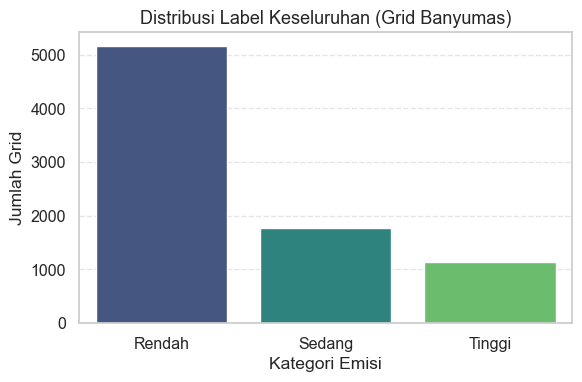

In [38]:
BASE = Path(r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT")
OUT  = BASE / "outputs"

def _first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None

primary = OUT / "grid_features_labeled.csv"

candidates = [
    primary,
    BASE / "emisi_banyumas_features_scored.csv",               
    OUT  / "tables" / "banyumas_features_no_label.csv",        
    OUT  / "tables" / "all_features_no_label.csv",              
]

found = _first_existing(candidates)
if found is None:
    # cari file yang mirip di seluruh proyek
    patterns = [
        str(BASE / "**" / "grid_features_labeled*.csv"),
        str(BASE / "**" / "*features_scored*.csv"),
        str(BASE / "**" / "*banyumas*features*.csv"),
    ]
    matches = []
    for pat in patterns:
        matches.extend(glob.glob(pat, recursive=True))
    if matches:
        found = Path(matches[0])

if found is None:
    raise FileNotFoundError(
        "Tidak menemukan file fitur berlabel. "
        "Jalankan blok fitur + labeling terlebih dahulu "
        "atau pastikan file CSV-nya berada di folder proyek."
    )

print(f"📄 Memuat: {found}")
feat = pd.read_csv(found)

rename_map = {}
if "emission_label" in feat.columns and "kategori_emisi" not in feat.columns:
    rename_map["emission_label"] = "kategori_emisi"
if "prediksi_kategori" in feat.columns and "kategori_emisi" not in feat.columns:
    rename_map["prediksi_kategori"] = "kategori_emisi"
feat = feat.rename(columns=rename_map)

if "kategori_emisi" not in feat.columns:
    # Coba pakai 'score' jika ada
    if "score" in feat.columns and pd.Series(feat["score"]).notna().any():
        s = pd.to_numeric(feat["score"], errors="coerce").fillna(0.0)
        if s.nunique() <= 1:
            feat["kategori_emisi"] = "Sedang"
        else:
            q1, q2 = s.quantile([1/3, 2/3]).tolist()
            feat["kategori_emisi"] = pd.cut(
                s, bins=[-np.inf, q1, q2, np.inf],
                labels=["Rendah","Sedang","Tinggi"],
                include_lowest=True
            ).astype(str)
    else:
        # Jika tidak ada 'score', coba bentuk score sederhana dari fitur umum
        need = {"road_km_per_km2","building_area_pct","green_area_pct"}
        if need.issubset(set(feat.columns)):
            def robust_norm(series, p=99):
                s = pd.to_numeric(series, errors="coerce").fillna(0.0)
                cap = np.nanpercentile(s, p)
                cap = cap if np.isfinite(cap) and cap>0 else 1.0
                return np.clip(s/cap, 0, 1)
            s = (0.3*robust_norm(feat["road_km_per_km2"]) +
                 0.4*robust_norm(feat["building_area_pct"]) -
                 0.3*robust_norm(feat["green_area_pct"]))
            feat["score"] = s
            q1, q2 = s.quantile([1/3, 2/3]).tolist()
            feat["kategori_emisi"] = pd.cut(
                s, bins=[-np.inf, q1, q2, np.inf],
                labels=["Rendah","Sedang","Tinggi"],
                include_lowest=True
            ).astype(str)
        else:
            raise KeyError(
                "Tidak ada 'kategori_emisi' dan tidak bisa membentuk label. "
                "Butuh kolom: score ATAU (road_km_per_km2, building_area_pct, green_area_pct)."
            )

# Plot distribusi
lbl_counts = (
    feat["kategori_emisi"]
    .value_counts()
    .reindex(["Rendah","Sedang","Tinggi"])
    .fillna(0)
    .astype(int)
)

plt.figure(figsize=(6,4))
sns.barplot(x=lbl_counts.index, y=lbl_counts.values, palette="viridis")
plt.title("Distribusi Label Keseluruhan (Grid Banyumas)", fontsize=13)
plt.xlabel("Kategori Emisi"); plt.ylabel("Jumlah Grid")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()


6) SPLITTING → train/test per kecamatan (hold-out kecamatan)

In [41]:
def alias(df, targets):
    for name in targets:
        if name in df.columns:
            return name
    return None

# Petakan/rename agar konsisten
rename_pairs = {}

# 1) luas hijau → hijau_m2
src = alias(feat, ["hijau_m2", "luas_hijau_m2", "green_m2"])
if src is None:
    raise KeyError("Kolom luas hijau tidak ditemukan (cari: hijau_m2 / luas_hijau_m2 / green_m2).")
if src != "hijau_m2":
    rename_pairs[src] = "hijau_m2"

# 2) luas bangunan → bangunan_m2
src = alias(feat, ["bangunan_m2", "luas_bangunan_m2", "building_m2"])
if src is None:
    raise KeyError("Kolom luas bangunan tidak ditemukan (cari: bangunan_m2 / luas_bangunan_m2 / building_m2).")
if src != "bangunan_m2":
    rename_pairs[src] = "bangunan_m2"

# 3) panjang jalan → jalan_m
src = alias(feat, ["jalan_m", "panjang_jalan_m", "road_m"])
if src is None:
    raise KeyError("Kolom panjang jalan tidak ditemukan (cari: jalan_m / panjang_jalan_m / road_m).")
if src != "jalan_m":
    rename_pairs[src] = "jalan_m"

# Lakukan rename jika perlu
if rename_pairs:
    feat = feat.rename(columns=rename_pairs)

# 4) Rasio hijau/bangunan
if "ratio_green_building" not in feat.columns:
    # coba alias lain
    src_ratio_gb = alias(feat, ["rasio_hijau_bangunan"])
    if src_ratio_gb:
        feat = feat.rename(columns={src_ratio_gb: "ratio_green_building"})
    else:
        # hitung jika bahan ada
        if {"hijau_m2", "bangunan_m2"}.issubset(feat.columns):
            feat["ratio_green_building"] = feat["hijau_m2"] / (feat["bangunan_m2"] + 1.0)
        else:
            raise KeyError("Tidak bisa membuat ratio_green_building (butuh hijau_m2 & bangunan_m2).")

# 5) Rasio jalan/bangunan
if "ratio_road_building" not in feat.columns:
    src_ratio_rb = alias(feat, ["rasio_jalan_bangunan"])
    if src_ratio_rb:
        feat = feat.rename(columns={src_ratio_rb: "ratio_road_building"})
    else:
        if {"jalan_m", "bangunan_m2"}.issubset(feat.columns):
            feat["ratio_road_building"] = feat["jalan_m"] / (feat["bangunan_m2"] + 1.0)
        else:
            raise KeyError("Tidak bisa membuat ratio_road_building (butuh jalan_m & bangunan_m2).")

# Pastikan kolom target ada
if "kategori_emisi" not in feat.columns:
    # fallback umum: beberapa file pake 'emission_label' atau 'prediksi_kategori'
    if "emission_label" in feat.columns:
        feat = feat.rename(columns={"emission_label": "kategori_emisi"})
    elif "prediksi_kategori" in feat.columns:
        feat = feat.rename(columns={"prediksi_kategori": "kategori_emisi"})
    else:
        raise KeyError("Kolom target 'kategori_emisi' tidak ada. Jalankan labeling terlebih dahulu.")

df_train = feat[feat["kecamatan"].isin(TRAIN_KEC)].copy()
df_test  = feat[feat["kecamatan"].isin(TEST_KEC)].copy()
assert (len(df_train)>0) and (len(df_test)>0), "Split kosong. Cek ejaan kecamatan & isi data."

FEATURES = ["hijau_m2","bangunan_m2","jalan_m","ratio_green_building","ratio_road_building"]

# Validasi akhir kolom fitur
missing = [c for c in FEATURES if c not in df_train.columns]
if missing:
    raise KeyError(f"Kolom fitur hilang di TRAIN: {missing}")

X_train = df_train[FEATURES].astype(float).fillna(0.0).values
y_train = df_train["kategori_emisi"].astype(str).values

X_test  = df_test[FEATURES].astype(float).fillna(0.0).values
y_test  = df_test["kategori_emisi"].astype(str).values

print("Distribusi TRAIN:", pd.Series(y_train).value_counts().to_dict())
print("Distribusi TEST :", pd.Series(y_test).value_counts().to_dict())


Distribusi TRAIN: {'Rendah': 239, 'Sedang': 79, 'Tinggi': 47}
Distribusi TEST : {'Rendah': 87, 'Sedang': 76, 'Tinggi': 50}


7) NORMALISASI → data siap model (fit scaler di TRAIN saja)
    (Balancing → setelah split, sebelum fit model)

In [42]:
# Oversampling HANYA di TRAIN
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# Normalisasi fit di TRAIN_BAL lalu transform TEST
scaler = StandardScaler(with_mean=True, with_std=True)
X_train_std = scaler.fit_transform(X_train_bal)
X_test_std  = scaler.transform(X_test)

# Label encoding untuk evaluasi/plot
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_bal)
y_test_enc  = le.transform(y_test)
classes = list(le.classes_)  # ['Rendah','Sedang','Tinggi']

8) MODELING (SVM) → model terlatih

In [43]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.1, 0.01, 0.001],
    "kernel": ["rbf"]
}
svm = SVC(probability=True, class_weight=None, random_state=42)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(svm, param_grid, scoring="f1_macro", cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_train_std, y_train_enc)

best_svm = gs.best_estimator_
print("[BEST PARAMS]:", gs.best_params_)
print("[CV F1_MACRO]:", round(gs.best_score_, 4))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[BEST PARAMS]: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
[CV F1_MACRO]: 0.9958


9) EVALUATION → F1, Confusion Matrix, Accuracy


Akurasi  : 0.9906
F1-Macro : 0.9890

=== Classification Report ===
              precision    recall  f1-score   support

      Rendah       1.00      1.00      1.00        87
      Sedang       1.00      0.97      0.99        76
      Tinggi       0.96      1.00      0.98        50

    accuracy                           0.99       213
   macro avg       0.99      0.99      0.99       213
weighted avg       0.99      0.99      0.99       213



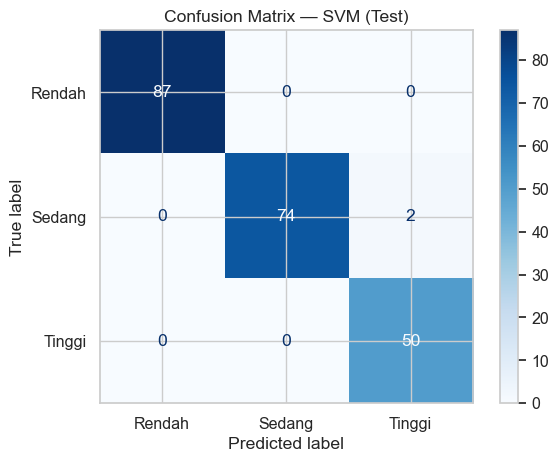

✅ Tersimpan: E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\outputs\prediksi_grid_test_svm.csv


In [45]:
y_pred_enc = best_svm.predict(X_test_std)
y_pred     = [classes[i] for i in y_pred_enc]

acc  = accuracy_score(y_test_enc, y_pred_enc)
f1m  = f1_score(y_test_enc, y_pred_enc, average="macro")
print(f"\nAkurasi  : {acc:.4f}")
print(f"F1-Macro : {f1m:.4f}\n")
print("=== Classification Report ===")
print(classification_report(y_test_enc, y_pred_enc, target_names=classes))

# Confusion Matrix (biarkan seperti kode kamu)
ConfusionMatrixDisplay.from_predictions(y_test_enc, y_pred_enc, display_labels=classes, cmap="Blues")
plt.title("Confusion Matrix — SVM (Test)")
plt.tight_layout(); plt.show()

# Simpan hasil prediksi per-grid test (ignore jika 'geometry' memang tidak ada)
pred_df = df_test.reset_index(drop=True).copy()
pred_df["prediksi_kategori"] = y_pred

OUT.mkdir(parents=True, exist_ok=True)  # pastikan folder ada
pred_df.drop(columns=["geometry"], errors="ignore") \
       .to_csv(OUT / "prediksi_grid_test_svm.csv", index=False, encoding="utf-8-sig")

print(f"✅ Tersimpan: {OUT/'prediksi_grid_test_svm.csv'}")
